# TensorFlow를 활용한 선형회귀 실습

이 노트북에서는 TensorFlow를 사용하여 간단한 선형회귀 문제를 풀어봅니다.

## 주요 단계
1. 데이터 생성 (y = 3x + 2 + 잡음)
2. 모델 정의 (Dense Layer)
3. 손실 함수 및 최적화 방법 설정
4. 학습 진행 및 시각화


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


## 1. 데이터 생성

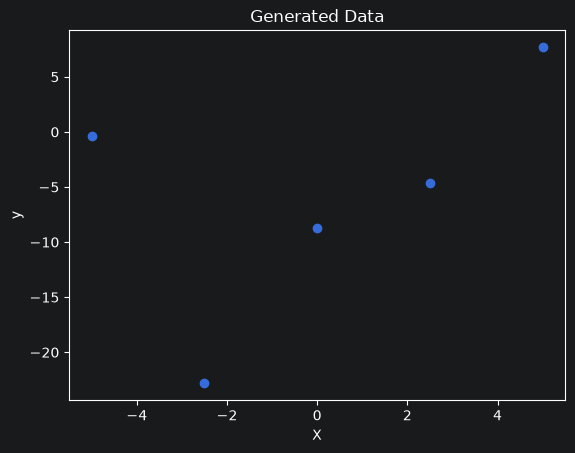

In [2]:
# y = 3x + 2 + noise
n_samples = 5
X = np.linspace(-5, 5, n_samples)
y = 3 * X + 2 + np.random.normal(0, 1, n_samples)*20

plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Data")
plt.show()

## 2. 모델 정의

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 모델 컴파일
- 손실 함수: MSE (Mean Squared Error)
- 최적화 방법: SGD (Stochastic Gradient Descent)

In [4]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

## 4. 모델 학습

Epoch 1/200
1/1 - 0s - 188ms/step - loss: 160.1657
Epoch 2/200
1/1 - 0s - 32ms/step - loss: 137.6496
Epoch 3/200
1/1 - 0s - 36ms/step - loss: 124.4604
Epoch 4/200
1/1 - 0s - 34ms/step - loss: 116.5385
Epoch 5/200
1/1 - 0s - 34ms/step - loss: 111.5992
Epoch 6/200
1/1 - 0s - 34ms/step - loss: 108.3568
Epoch 7/200
1/1 - 0s - 34ms/step - loss: 106.0873
Epoch 8/200
1/1 - 0s - 35ms/step - loss: 104.3827
Epoch 9/200
1/1 - 0s - 32ms/step - loss: 103.0128
Epoch 10/200
1/1 - 0s - 37ms/step - loss: 101.8474
Epoch 11/200
1/1 - 0s - 37ms/step - loss: 100.8127
Epoch 12/200
1/1 - 0s - 33ms/step - loss: 99.8666
Epoch 13/200
1/1 - 0s - 70ms/step - loss: 98.9847
Epoch 14/200
1/1 - 0s - 33ms/step - loss: 98.1527
Epoch 15/200
1/1 - 0s - 33ms/step - loss: 97.3622
Epoch 16/200
1/1 - 0s - 31ms/step - loss: 96.6077
Epoch 17/200
1/1 - 0s - 30ms/step - loss: 95.8858
Epoch 18/200
1/1 - 0s - 29ms/step - loss: 95.1940
Epoch 19/200
1/1 - 0s - 30ms/step - loss: 94.5304
Epoch 20/200
1/1 - 0s - 30ms/step - loss: 93.89

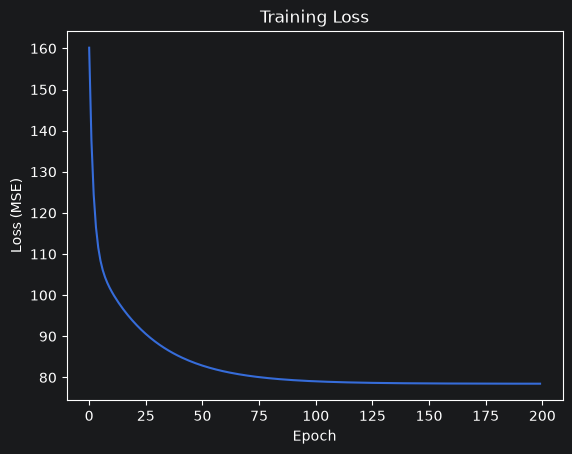

In [5]:
history = model.fit(X, y, epochs=200, verbose=2)

plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.show()

## 5. 결과 확인

학습된 기울기 W: 1.374, 절편 b: -5.664
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


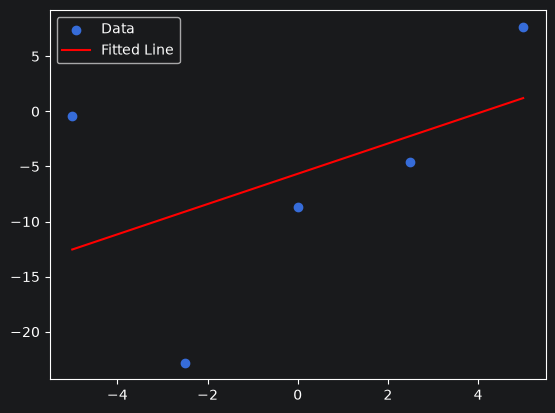

In [6]:
W, b = model.layers[0].get_weights()
print(f"학습된 기울기 W: {W[0][0]:.3f}, 절편 b: {b[0]:.3f}")

y_pred = model.predict(X)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.legend()
plt.show()

## 생각해보기
- 학습 샘플 수가 작아지면 어떻게 되는가?

추정된 파라미터(w, b)의 불안정성(분산)이 커집니다. 과적합이 발생할 수 있습니다.

- 학습 샘플에 잡음이 많으면 어떻게 되는가? 이 경우 학습 데이터가 많이 필요한가?

잡음이 많으면 추정이 더 불안정해 집니다. 이 경우 학습 데이터가 많아지면 잡음을 상쇄하여 과적합을 억제할 수 있ㅅ브니다.